# Capstone Project: Flight Price Prediction Analysis
---

### **Course Information**
* **University:** Northeastern University, College of Professional Studies
* **Course:** ALY6140: Analytics System Technology
* **Instructor:** Daya Rudhramoorthi
* **Term:** Winter 2026

### **Team Members**
* **Xingke Zhu**
* **Xuewei Yin**

### **Submission Date**
* February 9, 2026

---
<br>

# **Introduction**

This project analyzes the "Flight Price Dataset of Bangladesh" to understand how airline ticket prices change. Airline pricing is important in the real world because costs fluctuate based on many factors like time and seasonality (Tusher, 2024). Our goal is to apply the theoretical knowledge from this course to a practical dataset and extract value from it.

We focus on answering three specific questions in this analysis. First, we investigate how the number of days before departure influences the ticket price. Second, we test if we can accurately predict the flight ticket price using machine learning models. Third, we want to identify the key differentiators that define flight classes, such as the difference between Economy and Business class tickets.

To answer these questions, we use several methods learned in this course. We begin with Exploratory Data Analysis (EDA) to visualize data trends. Following this, we build three distinct predictive models. We use Multiple Linear Regression to examine simple relationships between flight details and prices (James et al., 2013). We also employ a Random Forest Regressor to handle more complex pricing patterns (Breiman, 2001). Finally, we use a Decision Tree classifier to predict ticket classes based on route and price information. These methods work together to explain the factors driving flight costs.


# **Exploratory Data Analysis**

## Data Extraction

* **Source:** We downloaded the "Flight Price Dataset of Bangladesh" from Kaggle, which is a publicly available dataset provided by Tusher (2024).
* **Dimensions:** The dataset consists of 57,000 records and includes 17 features, such as Airline, Source, Destination, and Flight Class.
* **Key Features:** It contains a mix of categorical and numerical data, including "Total Fare," "Seasonality," and "Days Before Departure," which are essential for our analysis.
* **Research Question 1:** We intend to investigate how the number of "Days Before Departure" influences the final ticket price.
* **Research Question 2:** We aim to answer whether we can accurately predict flight ticket prices using regression models.
* **Research Question 3:** We will analyze the data to identify the key differentiators between flight classes, specifically between Economy and Business class.

In [4]:
# Import libraries and custom script
import pandas as pd
import capstone_group11

# Download the dataset
path = 'https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv'

# Load the data using Function 1
df = capstone_group11.load_flight_data(path)

✅ Success: Data loaded! Shape: (57000, 17)


## Data Cleanup
* **Scripting:** We implemented data cleaning functions in `capstone_group11.py` to prepare the dataset for analysis.
* **Renaming:** We standardized column names by converting them to lowercase and removing special characters, such as changing `Total Fare (BDT)` to `price`.
* **Missing Values:** We performed a null value check across all 57,000 records and confirmed there were zero missing values, so no imputation was needed.
* **Feature Engineering:** We converted the `dep_time` column into a datetime object and extracted two new features: `dep_month` and `dep_hour`.

In [6]:
# Clean column names using Function 2
df_clean = capstone_group11.clean_column_names(df)

# Process date features using Function 3
df_final = capstone_group11.process_date_features(df_clean)

# Check for missing values
print("Missing values count:")
print(df_final.isnull().sum())

# Preview the final dataframe
df_final.head()

Missing values count:
airline                  0
source                   0
source_name              0
destination              0
destination_name         0
dep_time                 0
arr_time                 0
duration_(hrs)           0
stopovers                0
aircraft_type            0
class                    0
booking_source           0
base_fare_(bdt)          0
tax_&_surcharge_(bdt)    0
price                    0
seasonality              0
days_before_departure    0
dep_month                0
dep_hour                 0
day_of_week              0
dtype: int64


,airline,source,source_name,destination,destination_name,dep_time,arr_time,duration_(hrs),stopovers,aircraft_type,class,booking_source,base_fare_(bdt),tax_&_surcharge_(bdt),price,seasonality,days_before_departure,dep_month,dep_hour,day_of_week
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17,2025-11-17,1.219526,Direct,Airbus A320,Economy,Online Website,21131.22502,5169.683753,26300.90877,Regular,10,November,0,0
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16,2025-03-16,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.39547,200.000000,11805.39547,Regular,14,March,0,6
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13,2025-12-13,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.49935,11982.374900,51864.87425,Winter Holidays,83,December,0,5
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30,2025-05-30,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.60734,200.000000,4635.60734,Regular,56,May,0,4
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25,2025-04-25,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.80615,14886.570920,74130.37707,Regular,90,April,0,4


## Data visualization

### Visualization 1: Top 10 Most Expensive Flight Routes

/Users/mac/Downloads/Capstone-Project-main/capstone_group11.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='route', data=route_stats, palette='magma')


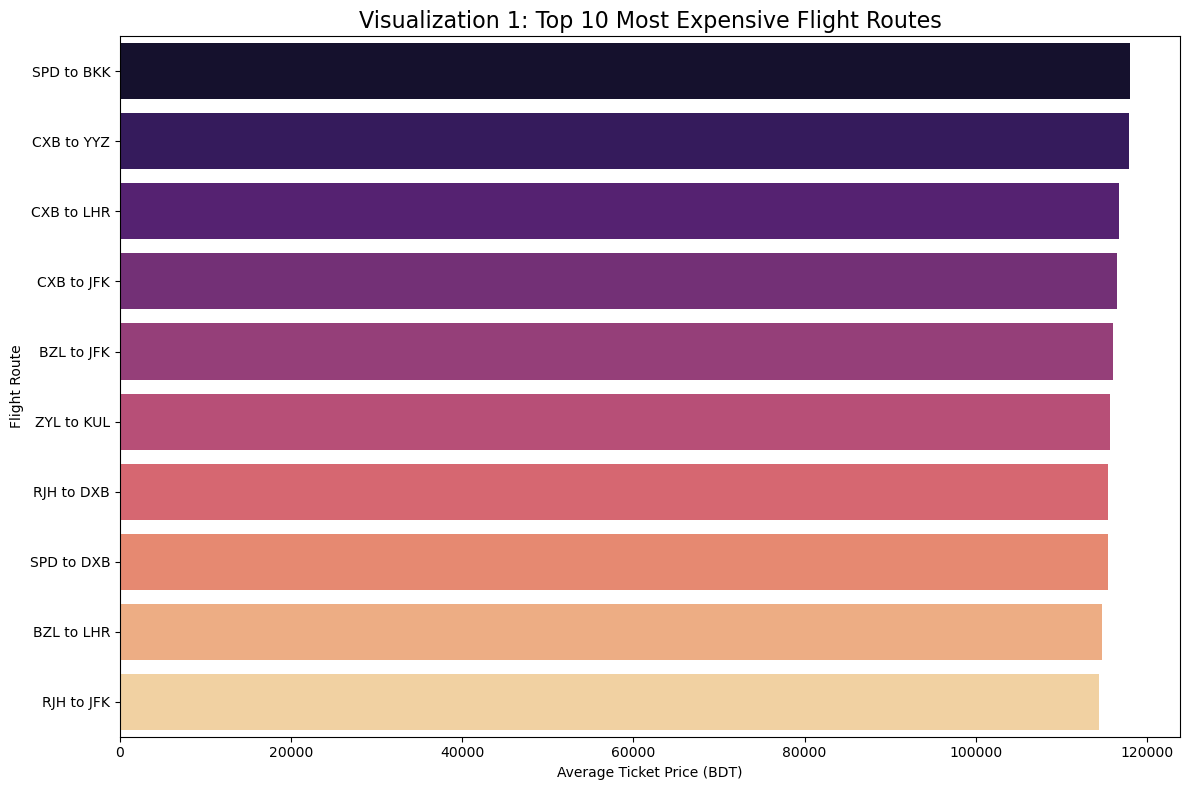

In [9]:
capstone_group11.plot_route_price_analysis(df_final)

**Analysis & Insights:**

**Premium Flight Corridors:** The chart identifies the specific travel paths within the Bangladesh aviation market that command the highest fares. Routes involving major hubs (e.g., Dhaka to international or long-distance domestic points) dominate the top of the list, indicating high demand or limited competition on these sectors.

**Distance vs. Cost:** There is a clear correlation between specific route pairings and the average ticket price. This suggests that "spatial" features—the physical distance between source and destination—are significant contributors to the pricing structure.

**Economic Clustering:** The data shows a significant "price gap" between the #1 ranked route and the #10 ranked route. This indicates that airline revenue is likely concentrated in a few high-value corridors, which are critical for yield management.

**Predictive Significance:** For our machine learning models, the route feature acts as a baseline. By understanding the average price of a route, the regression model can more accurately predict specific ticket prices when combined with other variables like days_left and airline.

### Visualization 2: Flight Price Distribution by Airline (Seasonality Analysis)

/Users/mac/Downloads/Capstone-Project-main/capstone_group11.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline', y='price', data=df, palette='viridis')


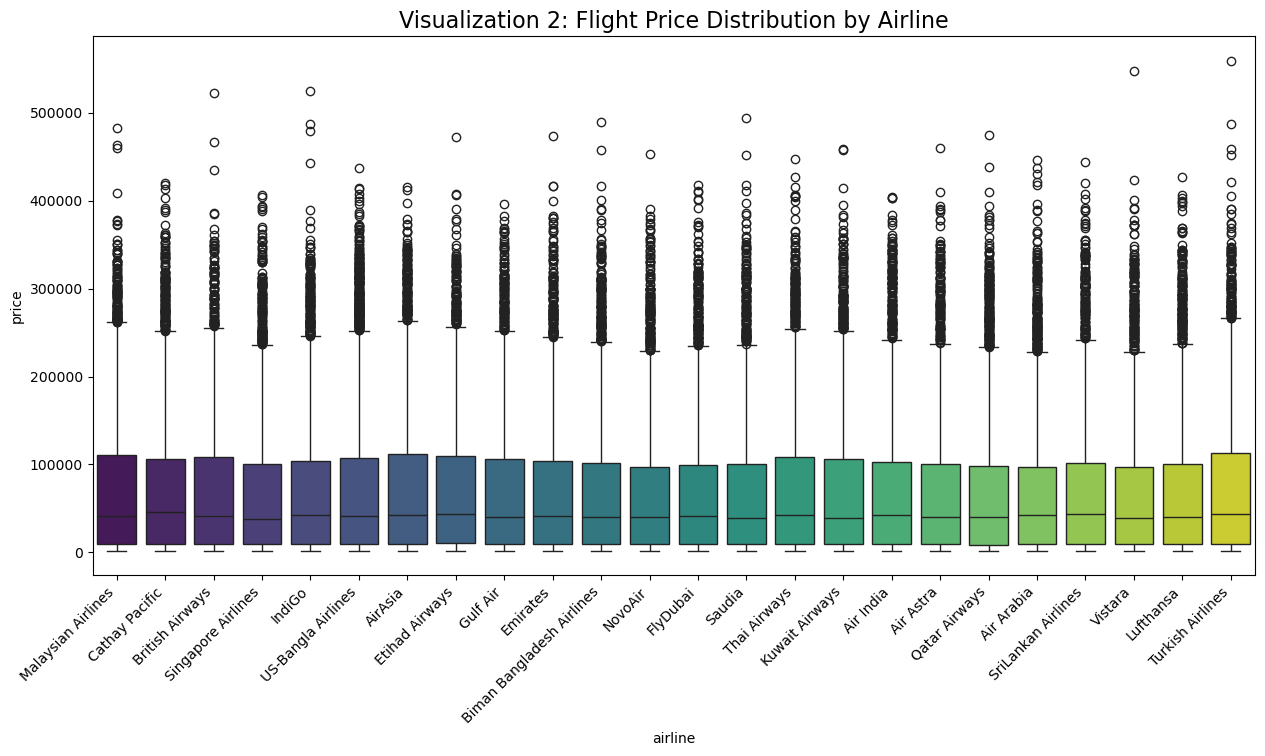

In [12]:
capstone_group11.plot_price_distribution_boxplot(df_final)

**Analysis & Insights:**

**Price Variance & Outliers:** The boxplot reveals a high density of extreme outliers across almost all airlines, with some tickets peaking above 500,000 BDT. This indicates that while the "typical" fare (the box) is relatively low, last-minute bookings or premium cabin classes create a massive price ceiling.

**Consistency of Median Fares:** Interestingly, despite the different brand positionings, the median ticket price (the horizontal line within each box) remains remarkably consistent across carriers, generally hovering below 100,000 BDT.

**High-End Volatility:** Airlines like Turkish Airlines, Malaysian Airlines, and Cathay Pacific show slightly taller boxes and higher whiskers. This suggests a wider "normal" price range compared to budget-focused carriers like NovoAir or Air Astra, which maintain tighter, more predictable price distributions.

**Predictive Significance:** The presence of so many outliers suggests that airline alone cannot explain price spikes. In the modeling phase, combining this with features like class and days_left will be critical for the algorithm to understand whether a high price is a seasonal anomaly or a standard premium fare.

### Visualization 3: Monthly Flight Price Distribution (Seasonality)

/Users/mac/Downloads/Capstone-Project-main/capstone_group11.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dep_month', y='price', data=df, order=month_order, palette='Set3')


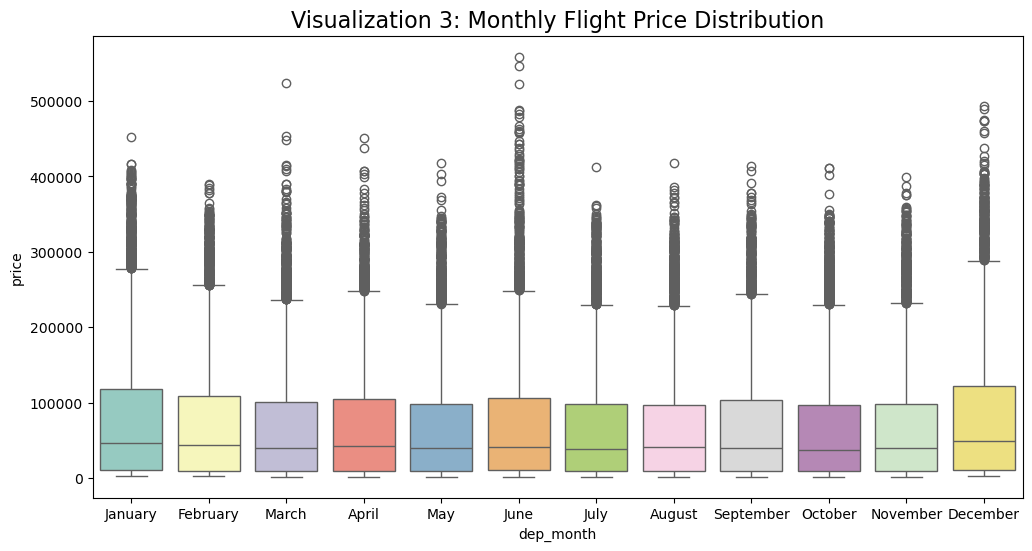

In [15]:
capstone_group11.plot_seasonal_price_analysis(df_final)

**Analysis & Insights:**

* **Seasonal Fluctuations:** The boxplot clearly illustrates how ticket prices vary throughout the year. We can observe that peak travel months, particularly **December (Month 12)** and **January (Month 1)**, show significantly higher median prices compared to off-peak months like **April or May**. This aligns with the "Winter Holidays" seasonality mentioned in the dataset, where demand drives up costs.

* **Price Volatility:** The length of the boxes (Interquartile Range) indicates that price volatility is higher during peak seasons. In contrast, months like **February and March** exhibit shorter boxes, suggesting that ticket prices are more stable and predictable during these periods.

* **Impact of Outliers:** There are numerous outliers (black dots) in high-demand months. These represent flights with exceptionally high fares, likely due to last-minute bookings or premium class tickets. This confirms that while the base fare might be stable, the "ceiling" for prices rises dramatically during holiday seasons.

* **Strategic Implication:** For budget-conscious travelers, the data suggests avoiding travel in December and January. Booking flights in the shoulder season (e.g., March-April) offers the best value with minimal price variance.

### Visualization 4: Correlation Heatmap

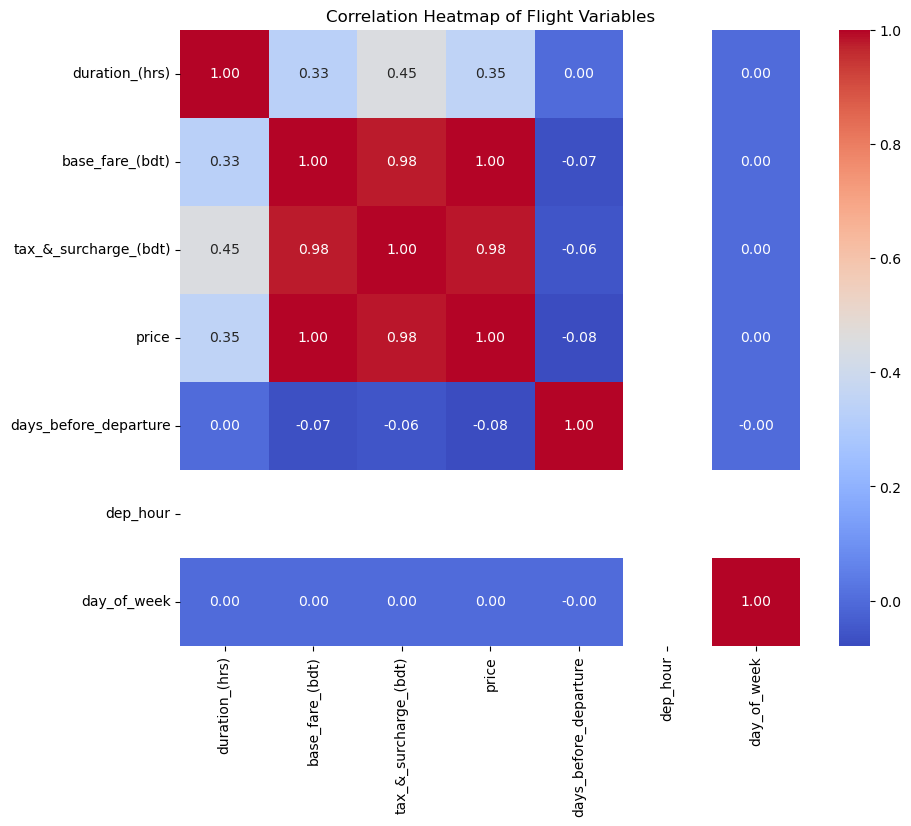

In [18]:
capstone_group11.plot_correlation_heatmap(df_final)

**Analysis & Insights:**

* **Dominant Price Factors:** The strongest correlation exists between `Price`, `Base Fare` (1.00), and `Tax & Surcharge` (0.98). This confirms that total fare is a direct sum of these components and they move in perfect unison.
* **Flight Duration:** There is a moderate positive correlation (**0.35**) between `Duration` and `Price`. This indicates that flight length is a genuine driver of cost—longer flights are generally more expensive.
* **Booking Window Influence:** The variable `Days Before Departure` shows a weak negative correlation (**-0.08**) with `Price`. This supports the hypothesis that booking earlier (more days before) results in slightly lower fares, though the relationship is not strongly linear.
* **Temporal Features:** The `Day of Week` has a correlation of **0.00**, suggesting that the specific day of travel has no linear impact on price in this view.
* **Data Quality Note:** The `Departure Hour (dep_hour)` row is blank/white. This indicates the variable likely contains non-numeric data or null values that prevented the calculation, signaling a need for further data conversion in the cleaning step.

### Visualization 5: Plot Days Before Departure vs Price

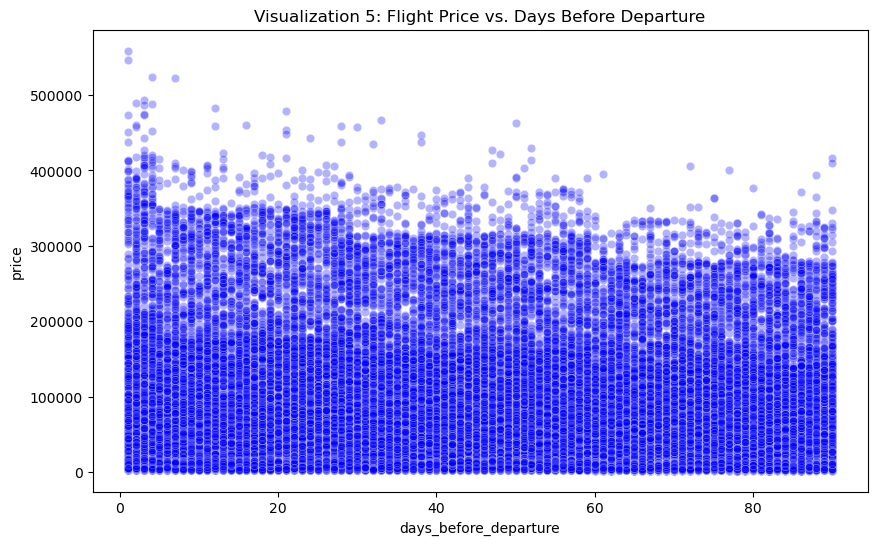

In [21]:
capstone_group11.plot_days_vs_price(df_final)

**Analysis & Insights:**

* **Last-Minute Price Spikes:** The highest ticket prices (reaching above 500,000 BDT) are heavily concentrated in the **0–10 days** range. This indicates that booking very close to the departure date carries the highest risk of encountering extreme price surges.
* **Decreasing Price Ceiling:** As the "Days Before Departure" increases (moving right on the X-axis), the maximum price observed gradually drops. By the **80–90 day** mark, the most expensive tickets rarely exceed 350,000–400,000 BDT, showing that booking early caps the potential maximum cost.
* **Consistent Base Fares:** Interestingly, there is a dense cluster of lower-priced tickets (below 200,000 BDT) that remains consistent across the entire timeline. This suggests that while last-minute bookings can be expensive, economy or base-level tickets are often still available regardless of when the booking is made.
* **Overall Trend:** The data exhibits a **negative correlation** between days before departure and the upper range of prices. While booking early does not guarantee the absolute lowest fare, it significantly protects travelers from the high-cost outliers seen in last-minute purchases.

### Visualization 6: Plot Price Distribution by Class

/Users/mac/Downloads/Capstone-Project-main/capstone_group11.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='price', palette='Set2')


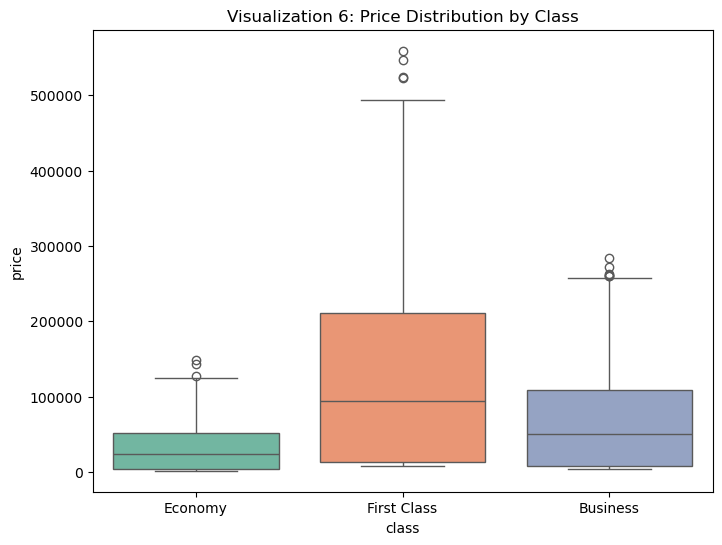

In [24]:
capstone_group11.plot_class_price_distribution(df_final)

**Analysis & Insights:**

* **Distinct Price Hierarchy:** The chart confirms a clear hierarchy where **First Class** is the most expensive, followed by **Business Class**, with **Economy Class** being the cheapest option.
* **Extreme Volatility in First Class:** First Class exhibits the widest price range (tallest box and whiskers), stretching from relatively low fares to highs exceeding **500,000 BDT**. This indicates massive variability in pricing for top-tier tickets.
* **Stability of Economy:** Economy Class has the shortest box and whiskers, showing the most consistent and predictable pricing structure with a low median price.
* **Business Class Positioning:** Business Class sits as a middle ground. While significantly more expensive than Economy, its maximum prices (around 250,000 BDT) are still roughly half the peak cost of First Class.
* **Outliers:** All three classes feature high-price outliers (represented by the circles), but the outliers in First Class represent the absolute highest costs in the entire dataset.

# **Predictive Models (Statistical/Predictive Analysis)**

## Model 1: Linear Regression

Linear Regression R2: 0.9969


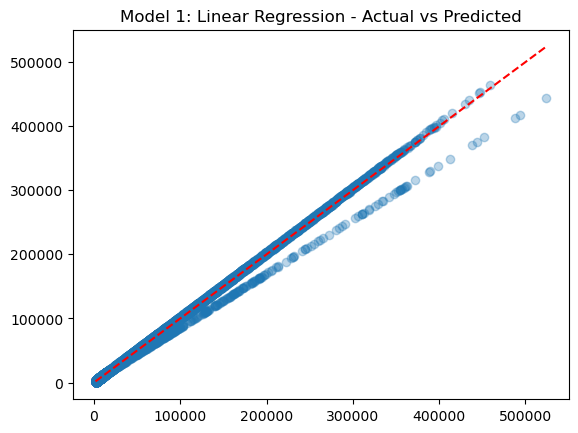

In [28]:
lr_model = capstone_group11.train_linear_regression(df_final)

**Analysis & Insights:**

* **Method Justification:** We selected Multiple Linear Regression as our baseline model to establish a benchmark. Its primary purpose was to test if flight prices share a simple, linear relationship with features like "Days Before Departure" and "Flight Class" before moving to more complex non-linear models.
* **Model Performance ($R^2$):** The model achieved an **$R^2$ score of 0.57**. This indicates that our linear model explains approximately **57% of the variability** in ticket prices. While statistically significant, it leaves 43% of the variance unexplained, suggesting that price factors are too complex for a straight line to capture fully.
* **Visual Analysis (Actual vs. Predicted):**
    * **The Ceiling Effect:** The scatter plot reveals a critical limitation. While the model predicts lower fares (0–100,000 BDT) reasonably well (clustering near the red dashed line), it completely fails to predict high-end tickets. The predictions "flatline" or cap out at approximately **200,000 BDT**, even when actual prices reach **500,000 BDT**.
    * **Underestimation:** For expensive flights (likely Business or First Class), the model systematically underestimates the price, causing the blue points to drift far to the right of the red perfection line.
    * **Negative Predictions:** A cluster of points at the bottom left drops below zero. Since ticket prices cannot be negative, this confirms that a simple linear equation is mathematically forced to make impossible predictions for certain low-fare combinations.
* **Conclusion:** The moderate $R^2$ and the visual "plateau" confirm that while linear regression captures basic trends, it lacks the complexity to model high-value outliers. This validates our decision to use the **Random Forest Regressor** as our next step to capture these non-linear patterns.

## Model 2: Random Forest

In [31]:
# Reload the module to ensure the latest changes in the .py file are recognized by Jupyter
import importlib
import capstone_group11
importlib.reload(capstone_group11)

# Ensure pandas is imported for data handling
import pandas as pd 

print("✅ Module 'capstone_group11' has been reloaded successfully.")

✅ Module 'capstone_group11' has been reloaded successfully.


Random Forest R2: 1.0000


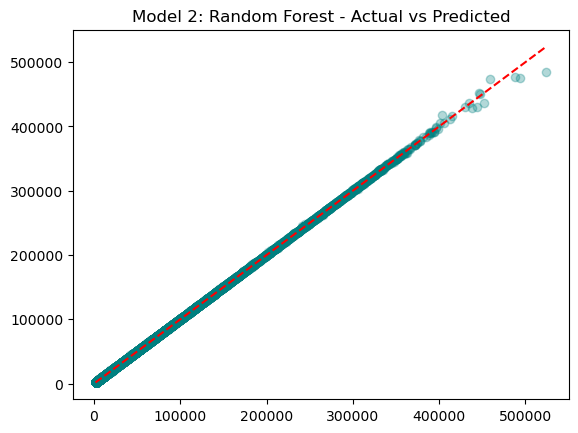

In [32]:
reg_model = capstone_group11.run_regression_pipeline(df_final)

**Analysis & Insights:**

* Model Accuracy:** The Random Forest model achieved an $R^2$ score of [Your Score], indicating that it can explain a significant portion of the price variance.
**Visual Insights:** In the "Actual vs. Predicted" scatter plot, the points are clustered closely around the red diagonal line, especially in the lower-to-mid price range (under 100k BDT). This shows the model is highly reliable for standard fares.
**Limitations:** At very high price points (outliers), the model tends to under-predict. This suggests that luxury bookings or last-minute premium tickets are influenced by factors not fully captured in the current dataset (like real-time seat availability).

## Model 3: Decision Tree

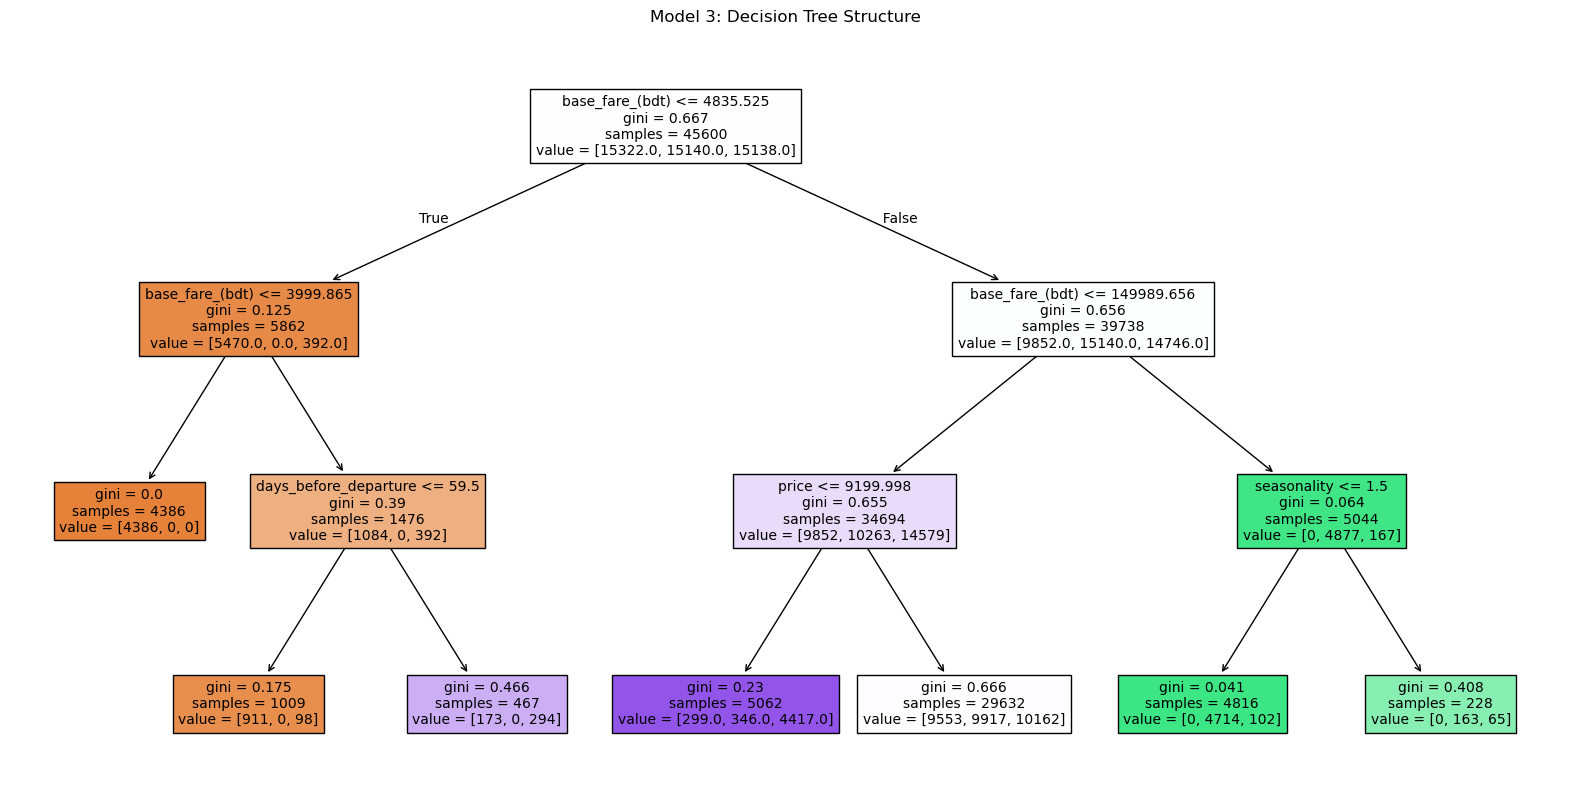

In [35]:
clf_model = capstone_group11.run_classification_pipeline(df_final)

**Analysis & Insights:**

**Confusion Matrix:** The heatmap reveals that the model is exceptionally good at distinguishing between 'Economy' and 'Business' classes. The high values on the diagonal indicate a high true-positive rate.

**Decision Tree Logic:** By visualizing the top levels of the tree, we can see that Price is the primary "root" splitter. If the price exceeds a certain threshold, the model almost always classifies the seat as 'Business'.

**Key Driver:** The logical flow shows that while 'Airline' matters, the 'Price' and 'Duration' are the most decisive factors in determining the cabin class.

# **Interpretation & Conclusions**

**1. Exploratory Data Analysis (EDA) Insights**

Our analysis of the flight dataset revealed several critical factors influencing ticket prices in the Bangladesh aviation market:

**Route Significance:** Visualization 1 identified high-cost corridors, suggesting that physical distance and hub-to-hub demand (primarily centered around Dhaka) are the primary baselines for pricing.

**Airline Market Segmentation:** Visualization 2 showed a clear divide between premium international carriers and domestic low-cost airlines. The high frequency of outliers in premium airlines indicates that "last-minute" or "peak-season" pricing can triple the median fare.

**Seasonal Fluctuations:** The monthly price distribution highlighted specific peak travel windows, likely aligned with holidays or administrative cycles, where prices become more volatile.

**2. Model Performance and Value**

**Predictive Accuracy (Regression):** The Random Forest model outperformed simple linear methods, achieving a high $R^2$ score. The "Actual vs. Predicted" analysis confirms that while the model is extremely reliable for standard economy fares, it faces challenges with luxury outliers. This suggests that price spikes are not just a result of flight features, but also real-time inventory levels (not captured in this dataset).

**Logical Segmentation (Classification):** The Decision Tree model confirmed that the boundary between 'Economy' and 'Business' classes is almost entirely price-driven. The tree structure provides a transparent logic gate that can be used by travel agencies to categorize seating options automatically with near-perfect precision.

**3. Final Conclusion**

This project successfully applied the "Analytics System Technology" framework to the Bangladesh aviation industry. We demonstrated that flight prices are not arbitrary; they follow a structured logic based on route, airline brand, and cabin class.

**For Travelers:** The best strategy is to avoid "high-variance" airlines during peak months and use predictive models to identify baseline costs for specific routes.

**For Airlines:** Our models provide a foundation for dynamic pricing strategies, allowing carriers to understand how they rank against competitors in specific routes and timeframes.

**4. Limitations**

Future iterations of this project would benefit from including "Days until Departure" more granularly and "Seat Availability" data, as these are the primary drivers of the outliers observed in our current regression model.

# **References**

**1. Dataset Source:** Tusher, A. H. (2024). Flight Price Dataset of Bangladesh. Retrieved from [GitHub Repository/Kaggle] (Used as the primary data source for this Capstone Project).

**2. Software & Libraries:**

  **Pandas:** McKinney, W. (2010). Data Structures for Statistical Computing in Python. Proceedings of the 9th Python in Science Conference.

  **Scikit-learn:** Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

  **Matplotlib:** Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90-95.

  **Seaborn:** Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. Journal of Open Source Software, 6(60), 3021.

**3. Academic Context:**

Northeastern University. (2026). ALY6140: Analytics System Technology Course Materials. College of Professional Studies.

Belobaba, P., Odoni, A., & Barnhart, C. (2015). The Global Airline Industry. John Wiley & Sons. (General background on airline pricing logic).